# 07. 변동성 소스 × Q 방식 전체 비교

## 비교 대상 (2 × 5 = 10가지)

| | Q_FIXED | Q_hist | Q_momentum | Q_lambda | Q_ff3 |
|---|---|---|---|---|---|
| **Baseline** (현재 vol_21d) | ✓ | ✓ | ✓ | ✓ | ✓ |
| **GARCH** (예측 vol) | ✓ | ✓ | ✓ | ✓ | ✓ |

> **Baseline 결과는 06번 결과물(`q_comparison_returns.csv`)에서 로드.**
> 이 노트북은 GARCH × 5Q 조합만 새로 계산하여 Baseline 결과와 합친다.
> 실행 전 **05_Q_Sensitivity.ipynb → 06_BL_Q_Comparison.ipynb 순서로 먼저 실행**해야 한다.

## Q_FIXED 값 자동 연결

| 변동성 소스 | Q_FIXED 출처 | 변수명 |
|---|---|---|
| **GARCH** walk-forward | `05_Q_Sensitivity` → `q_sensitivity_stats.csv` (Sharpe 최대 기준) | `Q_GARCH` |
| **Baseline** walk-forward | 06번에서 이미 적용 (`q_sensitivity_baseline_stats.csv`) | (06번 내부) |

## 실행 순서 의존성
```
04_VolatilityPrediction → vol_predicted.csv
05_Q_Sensitivity        → q_sensitivity_stats.csv          (Q_GARCH 자동 로드)
                        → q_sensitivity_baseline_stats.csv (06번 Q_FIXED 자동 로드)
06_BL_Q_Comparison      → q_comparison_returns.csv
         ↓
07_BL_VolQ_Grid (GARCH × 5Q만 새로 계산)
```

## 기간
- **2011-01 ~ 2025-12** (180개월) — GARCH 예측 시작 시점에 맞춰 통일

## 벤치마크
- CAPM 균형 최적화 (BL 없음)
- S&P 500 (SPY)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import io, re, zipfile, requests
import warnings
import platform
from pathlib import Path
from sklearn.covariance import LedoitWolf
from scipy.optimize import minimize

warnings.filterwarnings('ignore')
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / 'data'
OUT_DIR  = BASE_DIR / 'outputs' / '07_BL_VolQ_Grid'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── 파라미터 ────────────────────────────────────────────────
TRAIN_WINDOW    = 60
TAU             = 0.1
PCT_GROUP       = 0.30
START_PRED      = '2011-01-01'
MOMENTUM_WINDOW = 12
LAM_MEAN        = 2.5

# ── 05번 최적 Q 로드 ─────────────────────────────────────────
GARCH_STATS    = BASE_DIR / 'outputs' / '05_Q_Sensitivity' / 'q_sensitivity_stats.csv'
BASELINE_STATS = BASE_DIR / 'outputs' / '05_Q_Sensitivity' / 'q_sensitivity_baseline_stats.csv'

if GARCH_STATS.exists():
    _gs = pd.read_csv(GARCH_STATS, index_col='label')
    Q_GARCH = float(_gs['sharpe'].idxmax().split('=')[1])
    print(f'05번 GARCH 최적 Q 로드    → Q_GARCH    = {Q_GARCH}')
else:
    Q_GARCH = 0.003
    print(f'05번 GARCH 결과 없음 → 기본값: Q_GARCH = {Q_GARCH}')
    print('  (05_Q_Sensitivity.ipynb 먼저 실행하면 최적값이 자동 적용됩니다)')

if BASELINE_STATS.exists():
    _bs = pd.read_csv(BASELINE_STATS, index_col='label')
    Q_BASELINE = float(_bs['sharpe'].idxmax().split('=')[1])
    print(f'05번 Baseline 최적 Q 로드 → Q_BASELINE = {Q_BASELINE}')
else:
    Q_BASELINE = 0.003
    print(f'05번 Baseline 결과 없음 → 기본값: Q_BASELINE = {Q_BASELINE}')
    print('  (05_Q_Sensitivity.ipynb 먼저 실행하면 최적값이 자동 적용됩니다)')

print('※ Baseline 결과(Q_BASELINE 적용)는 06번 walk-forward에서 이미 계산됨')

# ── 데이터 로드 ──────────────────────────────────────────────
panel = pd.read_csv(DATA_DIR / 'monthly_panel.csv', parse_dates=['date'])
panel = panel.set_index(['date', 'ticker'])

all_dates  = panel.index.get_level_values('date').unique().sort_values()
pred_dates = all_dates[all_dates >= START_PRED]

ret_pivot  = panel['ret_1m'].unstack('ticker')
spy_series = panel['spy_ret'].groupby(level='date').first()
rf_series  = panel['rf_1m'].groupby(level='date').first()

print(f'패널: {panel.shape}')
print(f'예측 기간: {pred_dates[0].date()} ~ {pred_dates[-1].date()} ({len(pred_dates)}개월)')

In [6]:
# ── FF3 팩터 로드 ─────────────────────────────────────────────
FF3_PATH = DATA_DIR / 'ff3_monthly.csv'

def download_ff3():
    url = ('https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/'
           'F-F_Research_Data_Factors_CSV.zip')
    resp = requests.get(url, timeout=60)
    with zipfile.ZipFile(io.BytesIO(resp.content)) as zf:
        raw = zf.read(zf.namelist()[0]).decode('utf-8', errors='ignore')
    lines = raw.splitlines()
    start = next(i for i, l in enumerate(lines) if re.match(r'^\s*\d{6}\s*,', l))
    end   = next((i for i in range(start, len(lines))
                  if not re.match(r'^\s*\d{6}\s*,', lines[i])), len(lines))
    df = pd.read_csv(io.StringIO('\n'.join(lines[start-1:end])))
    df.columns = [c.strip() for c in df.columns]
    date_col = df.columns[0]
    df[date_col] = pd.to_datetime(df[date_col].astype(str), format='%Y%m') + pd.offsets.MonthEnd(0)
    df = df.rename(columns={date_col: 'date', 'Mkt-RF': 'mkt_rf',
                             'SMB': 'smb', 'HML': 'hml', 'RF': 'rf'})
    return df.set_index('date').astype(float) / 100.0

if FF3_PATH.exists():
    ff3 = pd.read_csv(FF3_PATH, index_col='date', parse_dates=True)
    print(f'FF3 로드: {ff3.shape}')
else:
    print('FF3 다운로드 중...')
    ff3 = download_ff3()
    ff3.to_csv(FF3_PATH)
    print(f'FF3 저장: {ff3.shape}')

# ── GARCH 예측 vol 로드 ──────────────────────────────────────
PRED_PATH = DATA_DIR / 'vol_predicted.csv'
assert PRED_PATH.exists(), '04_VolatilityPrediction.ipynb 먼저 실행해 vol_predicted.csv 생성하세요'
vol_pred_df    = pd.read_csv(PRED_PATH, parse_dates=['date'])
vol_pred_pivot = vol_pred_df.set_index(['date', 'ticker'])['vol_pred'].unstack('ticker')
print(f'GARCH 예측 로드: {vol_pred_pivot.shape}')

FF3 로드: (1196, 4)
GARCH 예측 로드: (180, 610)


In [7]:
# ── BL 구성 함수 ──────────────────────────────────────────────

def compute_sigma(ret_matrix):
    lw = LedoitWolf().fit(ret_matrix.values)
    return pd.DataFrame(lw.covariance_,
                        index=ret_matrix.columns,
                        columns=ret_matrix.columns)


def compute_pi(Sigma, w_mkt, spy_excess_ret, sigma2_mkt):
    lam = spy_excess_ret / sigma2_mkt if sigma2_mkt > 0 else 2.5
    lam = np.clip(lam, 0.5, 10.0)
    return lam * Sigma @ w_mkt, lam


def build_P(vol_series, mcap_series, pct=0.30):
    n_group    = max(1, int(len(vol_series) * pct))
    sorted_idx = vol_series.sort_values().index
    low_risk   = sorted_idx[:n_group]
    high_risk  = sorted_idx[-n_group:]
    P = pd.Series(0.0, index=vol_series.index)
    low_m  = mcap_series[low_risk]
    high_m = mcap_series[high_risk]
    P[low_risk]  =  low_m  / low_m.sum()
    P[high_risk] = -high_m / high_m.sum()
    return P


def compute_Q_hist(P, ret_matrix):
    p_vec = P.reindex(ret_matrix.columns).fillna(0).values
    return float((ret_matrix.values @ p_vec).mean())


def compute_Q_momentum(P, ret_matrix, window=12):
    """최근 window개월 P 포트폴리오 평균 실현수익률 (단기 추세 신호)"""
    n = min(window, len(ret_matrix))
    if n < 3:
        return compute_Q_hist(P, ret_matrix)
    p_vec  = P.reindex(ret_matrix.columns).fillna(0).values
    recent = ret_matrix.iloc[-n:]
    return float((recent.values @ p_vec).mean())


def compute_Q_lambda(lam, q_base, lam_mean=2.5):
    """Q = q_base × (λ_t / λ_mean) — 위험회피계수로 Q 강도 조정
    scale을 [0.1, 3.0]으로 제한하여 극단적 Q 발생 방지"""
    scale = np.clip(lam / lam_mean, 0.1, 3.0)
    return float(q_base * scale)


def compute_Q_ff3(P, ret_matrix, ff3_train, rf_train):
    view_tickers = [t for t in P[P != 0].index if t in ret_matrix.columns]
    if not view_tickers:
        return 0.0
    ff3_aligned = ff3_train.reindex(ret_matrix.index).dropna()
    rf_aligned  = rf_train.reindex(ff3_aligned.index).fillna(0)
    n = len(ff3_aligned)
    if n < 24:
        return 0.0
    X      = np.column_stack([np.ones(n), ff3_aligned[['mkt_rf', 'smb', 'hml']].values])
    X_next = np.array([1.0] + ff3_aligned[['mkt_rf', 'smb', 'hml']].tail(12).mean().tolist())
    rf_next = float(rf_train.iloc[-1]) if len(rf_train) > 0 else 0.0
    Y    = (ret_matrix[view_tickers].reindex(ff3_aligned.index).fillna(0).values
            - rf_aligned.values.reshape(-1, 1))
    coef = np.linalg.lstsq(X, Y, rcond=None)[0]
    r_hat_view = X_next @ coef + rf_next
    r_hat = pd.Series(0.0, index=ret_matrix.columns)
    for j, t in enumerate(view_tickers):
        r_hat[t] = r_hat_view[j]
    return float(P.reindex(ret_matrix.columns).fillna(0) @ r_hat)


def compute_omega(P, Sigma, tau):
    p = P.values
    return max(float(tau * p @ Sigma.values @ p), 1e-8)


def black_litterman(pi, Sigma, P, q, omega, tau):
    p    = P.values
    pi_v = pi.values
    tSig = tau * Sigma.values
    M      = float(p @ tSig @ p) + omega
    diff   = q - float(p @ pi_v)
    adjust = tSig @ p * (diff / M)
    return pd.Series(pi_v + adjust, index=pi.index)


def optimize_portfolio(mu, Sigma, lam):
    n   = len(mu)
    mu_ = mu.values
    Sig = Sigma.values
    def obj(w): return 0.5 * lam * w @ Sig @ w - w @ mu_
    def jac(w): return lam * Sig @ w - mu_
    res = minimize(obj, np.ones(n)/n, jac=jac, method='SLSQP',
                   bounds=[(0, 1)]*n,
                   constraints=[{'type': 'eq', 'fun': lambda w: w.sum()-1}])
    if not res.success:
        import warnings
        warnings.warn(f'optimize_portfolio 수렴 실패 → 1/N 대체: {res.message}')
    w = res.x if res.success else np.ones(n)/n
    return pd.Series(w, index=mu.index)


print('BL 함수 정의 완료')
print('Q 추정 함수: Q_hist | Q_momentum | Q_lambda | Q_ff3')


BL 함수 정의 완료
Q 추정 함수: Q_hist | Q_momentum | Q_lambda | Q_ff3


In [ ]:
# ── Step 1: 06번 Baseline 결과 로드 ──────────────────────────
Q06_PATH = DATA_DIR / 'q_comparison_returns.csv'
assert Q06_PATH.exists(), '06_BL_Q_Comparison.ipynb 먼저 실행하세요 (q_comparison_returns.csv 필요)'

q06_raw = pd.read_csv(Q06_PATH, parse_dates=['date'], index_col='date')
q06_raw = q06_raw[q06_raw.index >= pd.Timestamp(START_PRED)]

# 06 컬럼명(Q_FIXED, ...) → 07 형식(Baseline+Q_FIXED, ...)으로 rename
ret_series = {}
for col in ['Q_FIXED', 'Q_hist', 'Q_momentum', 'Q_lambda', 'Q_ff3']:
    ret_series[f'Baseline+{col}'] = q06_raw[col].dropna()
ret_series['CAPM'] = q06_raw['CAPM'].dropna()
ret_series['SPY']  = q06_raw['SPY'].dropna()

print('06번 Baseline 결과 로드 완료:')
for k, s in ret_series.items():
    print(f'  {k}: {len(s)}개월')

# ── Step 2: Walk-forward (GARCH × 5Q만 새로 계산) ────────────
# Q_GARCH: 05번 GARCH 민감도 분석에서 Sharpe 최대 기준 자동 로드
garch_results = {f'GARCH+{q}': []
                 for q in ['Q_FIXED', 'Q_hist', 'Q_momentum', 'Q_lambda', 'Q_ff3']}

print(f'\nWalk-forward (GARCH only): {pred_dates[0].date()} ~ {pred_dates[-1].date()} ({len(pred_dates)}개월)')
print(f'  Q_GARCH = {Q_GARCH}  (월 {Q_GARCH*100:.1f}%  |  연 {Q_GARCH*12*100:.1f}%)')

for i, pred_date in enumerate(pred_dates):
    if (i + 1) % 12 == 0:
        print(f'  {pred_date.date()} ({i+1}/{len(pred_dates)})')

    try:
        # GARCH vol이 없는 날짜는 건너뜀
        if pred_date not in vol_pred_pivot.index:
            continue

        month_base = panel.xs(pred_date, level='date').dropna(
            subset=['vol_21d', 'log_mcap', 'ret_1m'])
        if len(month_base) < 30:
            continue

        # GARCH vol 주입
        pred_vol = vol_pred_pivot.loc[pred_date].reindex(month_base.index)
        month_df = month_base.copy()
        month_df['vol_use'] = pred_vol
        month_df = month_df.dropna(subset=['vol_use'])
        if len(month_df) < 20:
            continue

        idx         = all_dates.get_loc(pred_date)
        train_dates = all_dates[max(0, idx - TRAIN_WINDOW): idx]
        rf_s        = rf_series.reindex(train_dates)
        spy_s       = spy_series.reindex(train_dates)
        spy_excess  = (spy_s - rf_s).mean()
        sigma2_mkt  = spy_s.var()

        universe  = month_df.index.tolist()
        thresh    = int(len(train_dates) * 0.7)
        ret_slice = (ret_pivot.reindex(index=train_dates, columns=universe)
                              .dropna(axis=1, thresh=thresh)
                              .fillna(0))
        valid_tix = ret_slice.columns.tolist()
        if len(valid_tix) < 20:
            continue

        month_df = month_df.reindex(valid_tix)
        Sigma    = compute_sigma(ret_slice)
        mcap     = np.exp(month_df['log_mcap'])
        w_mkt    = (mcap / mcap.sum()).reindex(valid_tix).fillna(0)
        pi, lam  = compute_pi(Sigma, w_mkt, spy_excess, sigma2_mkt)

        P     = build_P(month_df['vol_use'], mcap, pct=PCT_GROUP)
        P     = P.reindex(valid_tix).fillna(0)
        omega = compute_omega(P, Sigma, TAU)

        q_fixed    = Q_GARCH   # 05번 GARCH 최적 Q
        q_hist     = compute_Q_hist(P, ret_slice)
        q_momentum = compute_Q_momentum(P, ret_slice, window=MOMENTUM_WINDOW)
        q_lambda   = compute_Q_lambda(lam, Q_GARCH, lam_mean=LAM_MEAN)
        q_ff3      = compute_Q_ff3(P, ret_slice, ff3.reindex(train_dates), rf_s)

        next_date  = all_dates[idx + 1] if idx + 1 < len(all_dates) else None
        actual_ret = (ret_pivot.loc[next_date].reindex(valid_tix).fillna(0)
                            if next_date is not None
                            else month_df['fwd_ret_1m'].reindex(valid_tix).fillna(0))

        for q_name, q_val in [('Q_FIXED',    q_fixed),
                               ('Q_hist',     q_hist),
                               ('Q_momentum', q_momentum),
                               ('Q_lambda',   q_lambda),
                               ('Q_ff3',      q_ff3)]:
            mu_BL = black_litterman(pi, Sigma, P, q_val, omega, TAU)
            w_bl  = optimize_portfolio(mu_BL, Sigma, lam)
            garch_results[f'GARCH+{q_name}'].append(
                {'date': pred_date, 'ret': float(w_bl @ actual_ret)})

    except Exception as e:
        if i < 5:
            print(f'  [에러] {pred_date.date()}: {e}')

# ── Step 3: Baseline(로드) + GARCH(계산) 합치기 ───────────────
for k, v in garch_results.items():
    if v:
        ret_series[k] = pd.DataFrame(v).set_index('date')['ret']

print(f'\n완료')
for k, s in ret_series.items():
    print(f'  {k}: {len(s)}개월')


In [9]:
# ── 성과 분석 ────────────────────────────────────────────────
ANN        = np.sqrt(12)
rf_monthly = panel['rf_1m'].groupby(level='date').first()

def performance(ret, label):
    rf     = rf_monthly.reindex(ret.index).fillna(0)
    excess = ret - rf
    ann_ret = ret.mean() * 12
    ann_vol = ret.std() * ANN
    sharpe  = excess.mean() / excess.std() * ANN
    cum     = (1 + ret).cumprod()
    mdd     = ((cum - cum.cummax()) / cum.cummax()).min()
    cum_ret = cum.iloc[-1] - 1
    return {'label': label, 'ann_ret': ann_ret, 'ann_vol': ann_vol,
            'sharpe': sharpe, 'cum_ret': cum_ret, 'mdd': mdd}

# 표시 순서: Baseline 5종 → GARCH 5종 → 벤치마크
ORDER = [
    'Baseline+Q_FIXED', 'Baseline+Q_hist', 'Baseline+Q_momentum', 'Baseline+Q_lambda', 'Baseline+Q_ff3',
    'GARCH+Q_FIXED',    'GARCH+Q_hist',    'GARCH+Q_momentum',    'GARCH+Q_lambda',    'GARCH+Q_ff3',
    'CAPM', 'SPY',
]

stats_list = [performance(ret_series[k], k) for k in ORDER if k in ret_series]
stats_df   = pd.DataFrame(stats_list).set_index('label')

disp = stats_df.copy()
disp['ann_ret'] = disp['ann_ret'].map('{:.2%}'.format)
disp['ann_vol'] = disp['ann_vol'].map('{:.2%}'.format)
disp['sharpe']  = disp['sharpe'].map('{:.3f}'.format)
disp['cum_ret'] = disp['cum_ret'].map('{:.2%}'.format)
disp['mdd']     = disp['mdd'].map('{:.2%}'.format)
disp.columns    = ['연환산수익률', '연환산변동성', 'Sharpe', '누적수익률', 'MDD']

print('=' * 75)
print('전체 포트폴리오 성과 비교 (2011-01 ~ 2025-12)')
print('=' * 75)
print(disp.to_string())

# Baseline+Q_FIXED 대비 Sharpe 차이
base = stats_df.loc['Baseline+Q_FIXED', 'sharpe']
print(f'\nvs Baseline+Q_FIXED (Sharpe {base:.3f}):')
for name in ORDER[1:]:
    if name in stats_df.index:
        diff = stats_df.loc[name, 'sharpe'] - base
        print(f'  {name:30s}: {diff:+.3f}')

전체 포트폴리오 성과 비교 (2011-01 ~ 2025-12)
                     연환산수익률  연환산변동성 Sharpe    누적수익률      MDD
label                                                       
Baseline+Q_FIXED     13.77%  11.44%  1.074  608.29%  -13.70%
Baseline+Q_hist      14.19%  14.24%  0.896  613.83%  -21.57%
Baseline+Q_momentum  10.58%  15.33%  0.597  307.68%  -42.00%
Baseline+Q_lambda    13.73%  11.01%  1.112  609.29%  -11.84%
Baseline+Q_ff3       11.26%  16.79%  0.586  332.93%  -51.48%
GARCH+Q_FIXED        13.50%  11.81%  1.019  575.70%  -16.73%
GARCH+Q_hist         12.81%  13.24%  0.859  493.99%  -19.50%
GARCH+Q_momentum      9.34%  16.71%  0.473  225.51%  -50.85%
GARCH+Q_lambda       13.06%  11.53%  1.006  536.42%  -16.51%
GARCH+Q_ff3          11.42%  17.94%  0.557  331.08%  -54.37%
CAPM                 14.21%  14.49%  0.882  612.78%  -22.17%
SPY                  14.03%  14.06%  0.898  592.73%  -23.93%

vs Baseline+Q_FIXED (Sharpe 1.074):
  Baseline+Q_hist               : -0.178
  Baseline+Q_momentum           :

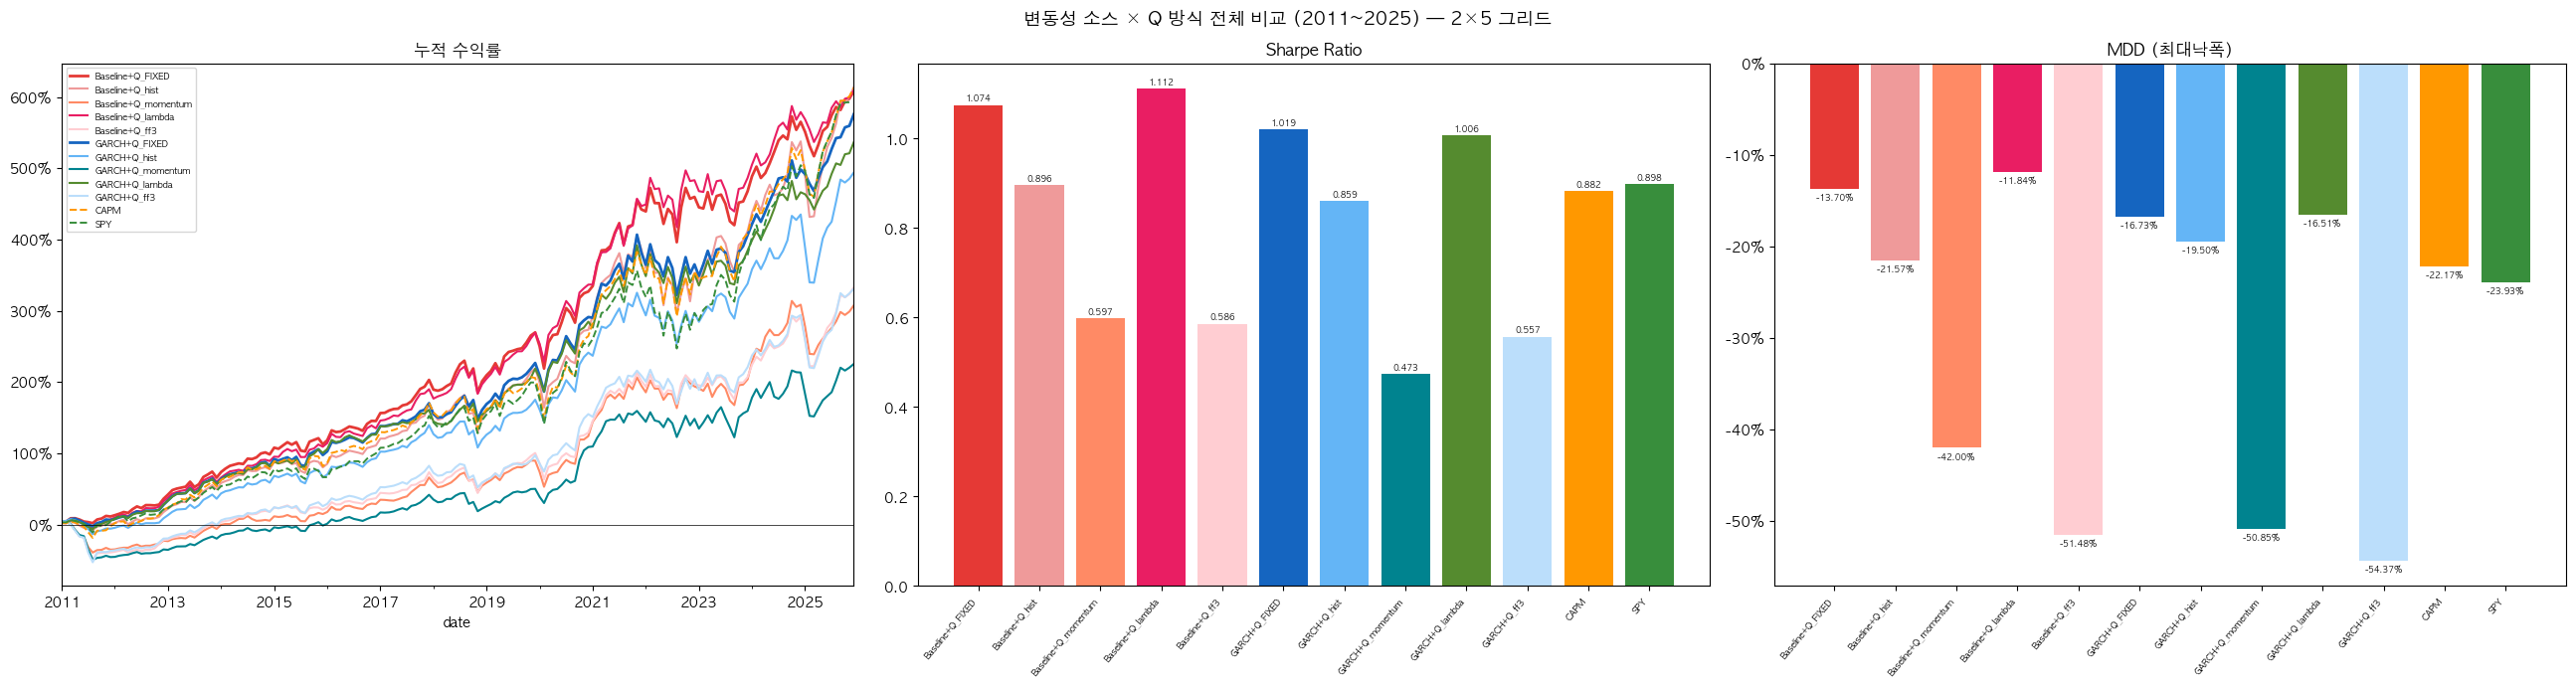

저장 완료


In [10]:
# ── 시각화 ───────────────────────────────────────────────────
# Baseline 계열: 붉은 계열 / GARCH 계열: 파란 계열
STYLE = {
    'Baseline+Q_FIXED':    ('#E53935', '-',  2.0),
    'Baseline+Q_hist':     ('#EF9A9A', '-',  1.5),
    'Baseline+Q_momentum': ('#FF8A65', '-',  1.5),
    'Baseline+Q_lambda':   ('#E91E63', '-',  1.5),
    'Baseline+Q_ff3':      ('#FFCDD2', '-',  1.5),
    'GARCH+Q_FIXED':       ('#1565C0', '-',  2.0),
    'GARCH+Q_hist':        ('#64B5F6', '-',  1.5),
    'GARCH+Q_momentum':    ('#00838F', '-',  1.5),
    'GARCH+Q_lambda':      ('#558B2F', '-',  1.5),
    'GARCH+Q_ff3':         ('#BBDEFB', '-',  1.5),
    'CAPM':                ('#FF9800', '--', 1.4),
    'SPY':                 ('#388E3C', '--', 1.4),
}

fig, axes = plt.subplots(1, 3, figsize=(26, 7))
fig.suptitle('변동성 소스 × Q 방식 전체 비교 (2011~2025) — 2×5 그리드', fontsize=13, fontweight='bold')

# ① 누적 수익률
ax = axes[0]
for k in ORDER:
    if k not in ret_series:
        continue
    color, ls, lw = STYLE[k]
    cum = (1 + ret_series[k]).cumprod() - 1
    cum.plot(ax=ax, label=k, color=color, linestyle=ls, linewidth=lw)
ax.set_title('누적 수익률')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(fontsize=6.5)
ax.axhline(0, color='black', linewidth=0.5)

# ② Sharpe Ratio
ax = axes[1]
keys    = [s['label'] for s in stats_list]
sharpes = [s['sharpe'] for s in stats_list]
colors  = [STYLE[k][0] for k in keys]
bars = ax.bar(range(len(keys)), sharpes, color=colors)
ax.set_xticks(range(len(keys)))
ax.set_xticklabels(keys, rotation=50, ha='right', fontsize=6.5)
ax.set_title('Sharpe Ratio')
ax.axhline(0, color='black', linewidth=0.5)
for bar, val in zip(bars, sharpes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=6, fontweight='bold')

# ③ MDD
ax = axes[2]
mdds = [s['mdd'] for s in stats_list]
bars = ax.bar(range(len(keys)), mdds, color=colors)
ax.set_xticks(range(len(keys)))
ax.set_xticklabels(keys, rotation=50, ha='right', fontsize=6.5)
ax.set_title('MDD (최대낙폭)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.axhline(0, color='black', linewidth=0.5)
for bar, val in zip(bars, mdds):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.005,
            f'{val:.2%}', ha='center', va='top', fontsize=6)

plt.tight_layout()
plt.savefig(OUT_DIR / 'vol_q_grid.png', dpi=150, bbox_inches='tight')
plt.show()

# 결과 저장
result_df = pd.DataFrame(ret_series)
result_df.to_csv(DATA_DIR / 'vol_q_grid_returns.csv')
stats_df.to_csv(OUT_DIR / 'vol_q_grid_stats.csv')
print('저장 완료')